EHR MODEL (MLP) TRAINING PIPELINE

Device: cpu
Data directory: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction
Model save path: /content/drive/MyDrive/MULTIMODAL/models/mlp_ehr_binary_diabetes.pth

STEP 1: LOADING PREPROCESSING CONFIGURATION

Preprocessing configuration loaded:
  Target column: diabetes
  Scaling method: standard
  Balancing strategy: undersample
  Balance train only: True
  Feature order: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
  Dataset sizes: {'train': 11876, 'val': 14422, 'test': 14422}

Number of features: 8

STEP 2: LOADING PREPROCESSED DATA

Datasets loaded:
  Training:   11,876 samples
  Validation: 14,422 samples
  Test:       14,422 samples

STEP 3: PREPARING DATA FOR TRAINING

Data shapes:
  X_train: (11876, 8), y_train: (11876,)
  X_val:   (14422, 8), y_val:   (14422,)
  X_test:  (14422, 8), y_test:  (14422,)

Class distribution:
  Train - Class 0: 5,938 (50.0%), Class

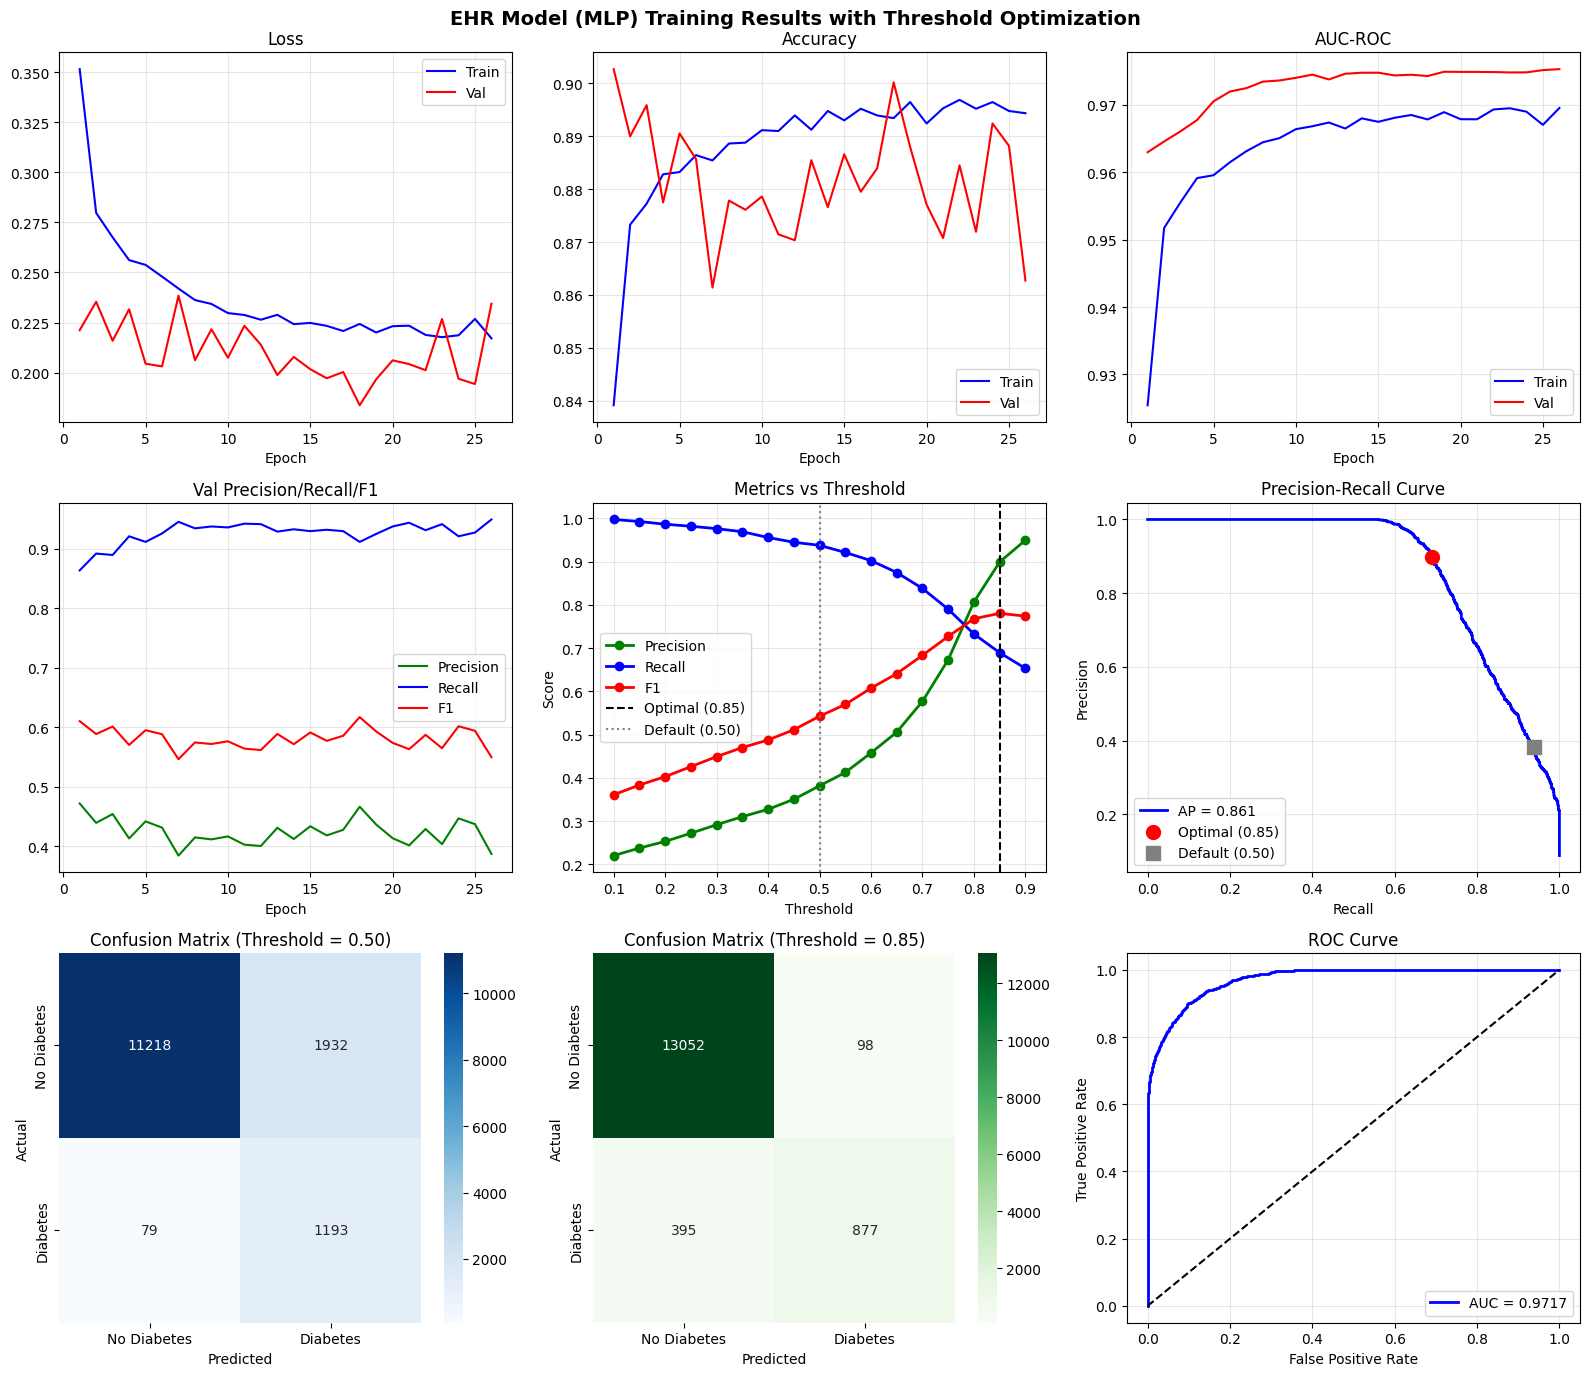

Saved: /content/drive/MyDrive/MULTIMODAL/models/ehr_training_results.png

TRAINING SUMMARY

Model: EHR MLP Classifier
─────────────────────────────────────────────────

Data (from preprocessing):
  Training samples:   11,876 (balanced: undersample)
  Validation samples: 14,422 (original distribution)
  Test samples:       14,422 (original distribution)
  Scaling:            standard

Architecture:
  Input features:     8
  Hidden layers:      [128, 64, 32]
  Feature dimension:  32
  Parameters:         11,969

Training:
  Epochs trained:     26
  Best epoch:         11
  Training time:      42.3s

Test Performance (Default Threshold = 0.50):
  Accuracy:           0.8606
  Precision:          0.3818
  Recall:             0.9379
  F1-Score:           0.5426

Test Performance (Optimal Threshold = 0.85):
  Accuracy:           0.9658
  Precision:          0.8995  (↑ 0.518)
  Recall:             0.6895  (↓ 0.248)
  F1-Score:           0.7806  (↑ 0.238)
  
AUC-ROC:              0.9717 (thresh

In [2]:
"""
================================================================================
EHR Model (MLP) for Binary Diabetes Detection
================================================================================

This notebook handles:
1. Loading preprocessed EHR datasets (pre-split and pre-scaled)
2. PyTorch MLP model definition
3. Model training with early stopping
4. Evaluation and metrics
5. Threshold optimization for precision-recall tradeoff
6. Visualization
7. Model saving for multimodal fusion

Input: ehr_train.csv, ehr_val.csv, ehr_test.csv (from preprocessing notebook)
Output: mlp_ehr_binary_diabetes.pth

Author: [Your Name]
Date: 2025
Project: Multimodal Federated Learning for Diabetes Detection
================================================================================
"""

# ============================================================================
# 1. IMPORTS
# ============================================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import json
import pickle
from typing import Dict, Tuple, List
import warnings

warnings.filterwarnings('ignore')

print("=" * 70)
print("EHR MODEL (MLP) TRAINING PIPELINE")
print("=" * 70)

# ============================================================================
# 2. CONFIGURATION
# ============================================================================

class EHRModelConfig:
    """Configuration for EHR model training."""

    # Paths - UPDATE THESE IF NEEDED
    DATA_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction"
    SAVE_DIR = "/content/drive/MyDrive/MULTIMODAL/models"
    MODEL_SAVE_NAME = "mlp_ehr_binary_diabetes.pth"

    # Preprocessed file names (from preprocessing notebook)
    TRAIN_FILE = "ehr_train.csv"
    VAL_FILE = "ehr_val.csv"
    TEST_FILE = "ehr_test.csv"
    CONFIG_FILE = "ehr_preprocessing_config.json"
    SCALER_FILE = "ehr_scaler.pkl"
    ENCODERS_FILE = "ehr_encoders.json"

    # Model architecture
    HIDDEN_DIMS = [128, 64, 32]  # Hidden layer dimensions
    DROPOUT_RATE = 0.3

    # Training hyperparameters
    BATCH_SIZE = 64
    NUM_EPOCHS = 100
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4

    # Early stopping
    PATIENCE = 15

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Reproducibility
    SEED = 42

config = EHRModelConfig()

# Create save directory
os.makedirs(config.SAVE_DIR, exist_ok=True)


def seed_everything(seed: int = 42):
    """Set random seeds for reproducibility."""
    import random
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(config.SEED)

print(f"\nDevice: {config.DEVICE}")
print(f"Data directory: {config.DATA_DIR}")
print(f"Model save path: {config.SAVE_DIR}/{config.MODEL_SAVE_NAME}")

# ============================================================================
# 3. LOAD PREPROCESSING CONFIGURATION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 1: LOADING PREPROCESSING CONFIGURATION")
print("=" * 70)

# Load preprocessing config
config_path = os.path.join(config.DATA_DIR, config.CONFIG_FILE)
if not os.path.exists(config_path):
    raise FileNotFoundError(
        f"Preprocessing config not found at: {config_path}\n"
        "Please run the preprocessing notebook first!"
    )

with open(config_path, 'r') as f:
    preprocess_config = json.load(f)

print(f"\nPreprocessing configuration loaded:")
print(f"  Target column: {preprocess_config['target_column']}")
print(f"  Scaling method: {preprocess_config['scaling_method']}")
print(f"  Balancing strategy: {preprocess_config['balancing_strategy']}")
print(f"  Balance train only: {preprocess_config['balance_train_only']}")
print(f"  Feature order: {preprocess_config['feature_order']}")
print(f"  Dataset sizes: {preprocess_config['dataset_sizes']}")

# Extract key info
TARGET_COLUMN = preprocess_config['target_column']
FEATURE_NAMES = preprocess_config['feature_order']
n_features = len(FEATURE_NAMES)

print(f"\nNumber of features: {n_features}")

# ============================================================================
# 4. LOAD PREPROCESSED DATA
# ============================================================================

print("\n" + "=" * 70)
print("STEP 2: LOADING PREPROCESSED DATA")
print("=" * 70)

# Define file paths
train_path = os.path.join(config.DATA_DIR, config.TRAIN_FILE)
val_path = os.path.join(config.DATA_DIR, config.VAL_FILE)
test_path = os.path.join(config.DATA_DIR, config.TEST_FILE)

# Check if files exist
for path, name in [(train_path, 'Train'), (val_path, 'Val'), (test_path, 'Test')]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{name} data not found at: {path}\n"
            "Please run the preprocessing notebook first!"
        )

# Load datasets
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print(f"\nDatasets loaded:")
print(f"  Training:   {len(df_train):,} samples")
print(f"  Validation: {len(df_val):,} samples")
print(f"  Test:       {len(df_test):,} samples")

# Verify columns match expected feature order
expected_columns = FEATURE_NAMES + [TARGET_COLUMN]
for df, name in [(df_train, 'Train'), (df_val, 'Val'), (df_test, 'Test')]:
    if list(df.columns) != expected_columns:
        print(f"\n⚠️  Warning: {name} columns don't match expected order")
        print(f"  Expected: {expected_columns}")
        print(f"  Found: {list(df.columns)}")

# ============================================================================
# 5. PREPARE DATA FOR TRAINING
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: PREPARING DATA FOR TRAINING")
print("=" * 70)

# Extract features and labels (data is already scaled from preprocessing)
X_train = df_train[FEATURE_NAMES].values.astype(np.float32)
y_train = df_train[TARGET_COLUMN].values.astype(np.float32)

X_val = df_val[FEATURE_NAMES].values.astype(np.float32)
y_val = df_val[TARGET_COLUMN].values.astype(np.float32)

X_test = df_test[FEATURE_NAMES].values.astype(np.float32)
y_test = df_test[TARGET_COLUMN].values.astype(np.float32)

print(f"\nData shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")

print(f"\nClass distribution:")
print(f"  Train - Class 0: {sum(y_train == 0):,} ({100*sum(y_train == 0)/len(y_train):.1f}%), "
      f"Class 1: {sum(y_train == 1):,} ({100*sum(y_train == 1)/len(y_train):.1f}%)")
print(f"  Val   - Class 0: {sum(y_val == 0):,} ({100*sum(y_val == 0)/len(y_val):.1f}%), "
      f"Class 1: {sum(y_val == 1):,} ({100*sum(y_val == 1)/len(y_val):.1f}%)")
print(f"  Test  - Class 0: {sum(y_test == 0):,} ({100*sum(y_test == 0)/len(y_test):.1f}%), "
      f"Class 1: {sum(y_test == 1):,} ({100*sum(y_test == 1)/len(y_test):.1f}%)")

# Note: Data is already scaled - no need to scale again
print(f"\n✓ Data is pre-scaled (from preprocessing)")
print(f"  Train data range: [{X_train.min():.2f}, {X_train.max():.2f}]")

# ============================================================================
# 6. CREATE DATALOADERS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: CREATE DATALOADERS")
print("=" * 70)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============================================================================
# 7. MODEL DEFINITION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: MODEL DEFINITION")
print("=" * 70)


class EHRClassifier(nn.Module):
    """
    Multi-Layer Perceptron for EHR tabular data classification.

    Features:
        - Flexible hidden layer configuration
        - BatchNorm for training stability
        - Dropout for regularization
        - Feature extraction method for multimodal fusion

    Architecture:
        Input (n_features) → [Linear → BatchNorm → ReLU → Dropout] × n_layers → Sigmoid
    """

    def __init__(
        self,
        n_features: int,
        hidden_dims: List[int] = [128, 64, 32],
        dropout_rate: float = 0.3
    ):
        super(EHRClassifier, self).__init__()

        self.n_features = n_features
        self.hidden_dims = hidden_dims

        # Build layers
        layers = []
        in_dim = n_features

        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim

        self.feature_extractor = nn.Sequential(*layers)

        # Feature dimension for multimodal fusion
        self.feature_dim = hidden_dims[-1]

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dims[-1], 1),
            nn.Sigmoid()
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize weights using Xavier initialization."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract features for multimodal fusion.

        Parameters
        ----------
        x : torch.Tensor
            Input features of shape (B, n_features).

        Returns
        -------
        torch.Tensor
            Feature vector of shape (B, feature_dim).
        """
        return self.feature_extractor(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Parameters
        ----------
        x : torch.Tensor
            Input features of shape (B, n_features).

        Returns
        -------
        torch.Tensor
            Binary predictions of shape (B, 1), values in [0, 1].
        """
        features = self.feature_extractor(x)
        output = self.classifier(features)
        return output


# Create model
model = EHRClassifier(
    n_features=n_features,
    hidden_dims=config.HIDDEN_DIMS,
    dropout_rate=config.DROPOUT_RATE
)
model = model.to(config.DEVICE)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(f"  Input features: {n_features}")
print(f"  Hidden layers: {config.HIDDEN_DIMS}")
print(f"  Feature dimension (for fusion): {model.feature_dim}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

print(f"\nModel structure:")
print(model)

# ============================================================================
# 8. TRAINING UTILITIES
# ============================================================================


class EarlyStopping:
    """Early stopping to prevent overfitting."""

    def __init__(self, patience: int = 15, min_delta: float = 0.001, mode: str = 'max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0

    def __call__(self, score: float, epoch: int) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
        elif self._is_improvement(score):
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def _is_improvement(self, score: float) -> bool:
        if self.mode == 'min':
            return score < self.best_score - self.min_delta
        return score > self.best_score + self.min_delta


class MetricsTracker:
    """Track training metrics."""

    def __init__(self):
        self.history = {
            'train_loss': [], 'train_acc': [], 'train_auc': [],
            'val_loss': [], 'val_acc': [], 'val_auc': [],
            'val_precision': [], 'val_recall': [], 'val_f1': [],
            'learning_rate': []
        }

    def update(self, metrics: Dict[str, float]):
        for key, value in metrics.items():
            if key in self.history:
                self.history[key].append(value)

    def get_best_metrics(self) -> Dict[str, float]:
        if not self.history['val_auc']:
            return {}
        best_idx = np.argmax(self.history['val_auc'])
        return {
            'epoch': best_idx + 1,
            'val_auc': self.history['val_auc'][best_idx],
            'val_acc': self.history['val_acc'][best_idx],
            'val_f1': self.history['val_f1'][best_idx]
        }


# ============================================================================
# 9. TRAINING FUNCTIONS
# ============================================================================


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        all_preds.extend(outputs.detach().cpu().numpy().flatten())
        all_labels.extend(y_batch.detach().cpu().numpy().flatten())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    epoch_acc = accuracy_score(all_labels, (all_preds > 0.5).astype(int))
    try:
        epoch_auc = roc_auc_score(all_labels, all_preds)
    except:
        epoch_auc = 0.5

    return {'loss': epoch_loss, 'accuracy': epoch_acc, 'auc': epoch_auc}


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_preds_binary = (all_preds > 0.5).astype(int)

    try:
        auc = roc_auc_score(all_labels, all_preds)
    except:
        auc = 0.5

    metrics = {
        'loss': epoch_loss,
        'accuracy': accuracy_score(all_labels, all_preds_binary),
        'auc': auc,
        'precision': precision_score(all_labels, all_preds_binary, zero_division=0),
        'recall': recall_score(all_labels, all_preds_binary, zero_division=0),
        'f1': f1_score(all_labels, all_preds_binary, zero_division=0)
    }

    return metrics, all_preds, all_labels


# ============================================================================
# 10. TRAINING LOOP
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: MODEL TRAINING")
print("=" * 70)
print(f"\nTraining configuration:")
print(f"  Epochs: {config.NUM_EPOCHS}")
print(f"  Batch size: {config.BATCH_SIZE}")
print(f"  Learning rate: {config.LEARNING_RATE}")
print(f"  Early stopping patience: {config.PATIENCE}")
print(f"  Device: {config.DEVICE}")
print("=" * 70 + "\n")

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
)

# Initialize tracking
metrics_tracker = MetricsTracker()
early_stopping = EarlyStopping(patience=config.PATIENCE, mode='max')
best_model_state = None
best_val_auc = 0.0

start_time = time.time()

for epoch in range(1, config.NUM_EPOCHS + 1):
    # Train
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, config.DEVICE)

    # Validate
    val_metrics, val_preds, val_labels = validate(model, val_loader, criterion, config.DEVICE)

    # Update scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_metrics['auc'])

    # Track metrics
    metrics_tracker.update({
        'train_loss': train_metrics['loss'],
        'train_acc': train_metrics['accuracy'],
        'train_auc': train_metrics['auc'],
        'val_loss': val_metrics['loss'],
        'val_acc': val_metrics['accuracy'],
        'val_auc': val_metrics['auc'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_f1': val_metrics['f1'],
        'learning_rate': current_lr
    })

    # Print progress
    if epoch % 10 == 0 or epoch == 1 or val_metrics['auc'] > best_val_auc:
        print(f"Epoch {epoch:3d} | "
              f"Train Loss: {train_metrics['loss']:.4f} | "
              f"Val AUC: {val_metrics['auc']:.4f} | "
              f"Val Acc: {val_metrics['accuracy']:.4f}", end="")
        if val_metrics['auc'] > best_val_auc:
            print(" ✓ Best!", end="")
        print()

    # Save best model
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        best_model_state = copy.deepcopy(model.state_dict())

        # Save checkpoint with preprocessing info
        checkpoint_path = os.path.join(config.SAVE_DIR, config.MODEL_SAVE_NAME)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_metrics['auc'],
            'val_acc': val_metrics['accuracy'],
            'n_features': n_features,
            'feature_names': FEATURE_NAMES,
            'hidden_dims': config.HIDDEN_DIMS,
            'feature_dim': model.feature_dim,
            'dropout_rate': config.DROPOUT_RATE,
            # Reference to preprocessing config
            'preprocess_config': preprocess_config,
            'data_dir': config.DATA_DIR,
        }, checkpoint_path)

    # Early stopping
    if early_stopping(val_metrics['auc'], epoch):
        print(f"\n⚠ Early stopping at epoch {epoch}")
        print(f"  Best epoch: {early_stopping.best_epoch} with AUC: {early_stopping.best_score:.4f}")
        break

total_time = time.time() - start_time

print("\n" + "=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)
print(f"Total time: {total_time:.1f} seconds ({total_time/60:.2f} minutes)")
print(f"Best validation AUC: {best_val_auc:.4f}")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# ============================================================================
# 11. FINAL EVALUATION (WITH DEFAULT THRESHOLD 0.5)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 7: FINAL EVALUATION ON TEST SET")
print("=" * 70)

test_metrics, test_preds, test_labels = validate(model, test_loader, criterion, config.DEVICE)

print(f"\n--- Results with Default Threshold (0.5) ---")
print(f"  Accuracy:    {test_metrics['accuracy']:.4f}")
print(f"  AUC-ROC:     {test_metrics['auc']:.4f}")
print(f"  Precision:   {test_metrics['precision']:.4f}")
print(f"  Recall:      {test_metrics['recall']:.4f}")
print(f"  F1-Score:    {test_metrics['f1']:.4f}")

# Calculate specificity with default threshold
test_preds_binary_default = (np.array(test_preds) > 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(test_labels, test_preds_binary_default).ravel()
specificity_default = tn / (tn + fp)
print(f"  Specificity: {specificity_default:.4f}")

print("\nClassification Report (Threshold = 0.5):")
print(classification_report(
    test_labels, test_preds_binary_default,
    target_names=['No Diabetes (0)', 'Diabetes (1)']
))

# ============================================================================
# 12. THRESHOLD OPTIMIZATION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 8: THRESHOLD OPTIMIZATION")
print("=" * 70)

print("\nSearching for optimal threshold to improve precision-recall tradeoff...")
print("\n" + "-" * 70)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Accuracy':<12}")
print("-" * 70)

# Convert to numpy arrays
test_preds_np = np.array(test_preds)
test_labels_np = np.array(test_labels)

# Search over thresholds
thresholds = np.linspace(0.1, 0.9, 17)
threshold_results = []

best_f1 = 0
best_threshold_f1 = 0.5

best_balanced = 0
best_threshold_balanced = 0.5

for thr in thresholds:
    preds_bin = (test_preds_np >= thr).astype(int)

    p = precision_score(test_labels_np, preds_bin, zero_division=0)
    r = recall_score(test_labels_np, preds_bin, zero_division=0)
    f1 = f1_score(test_labels_np, preds_bin, zero_division=0)
    acc = accuracy_score(test_labels_np, preds_bin)

    # Store results
    threshold_results.append({
        'threshold': thr,
        'precision': p,
        'recall': r,
        'f1': f1,
        'accuracy': acc
    })

    print(f"{thr:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f} {acc:<12.3f}")

    # Track best F1
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_f1 = thr

    # Track best balanced (geometric mean of precision and recall)
    balanced = np.sqrt(p * r) if p > 0 and r > 0 else 0
    if balanced > best_balanced:
        best_balanced = balanced
        best_threshold_balanced = thr

print("-" * 70)

print(f"\n✓ Best F1-Score Threshold: {best_threshold_f1:.2f} (F1 = {best_f1:.3f})")
print(f"✓ Best Balanced Threshold: {best_threshold_balanced:.2f}")

# ============================================================================
# 13. FIND THRESHOLD FOR TARGET PRECISION
# ============================================================================

print("\n" + "-" * 50)
print("Finding threshold for target precision levels...")
print("-" * 50)

target_precisions = [0.5, 0.6, 0.7, 0.8]

for target_p in target_precisions:
    # Find threshold that achieves target precision
    for result in sorted(threshold_results, key=lambda x: x['threshold']):
        if result['precision'] >= target_p:
            print(f"  Precision ≥ {target_p:.1f}: threshold = {result['threshold']:.2f} "
                  f"(P={result['precision']:.3f}, R={result['recall']:.3f}, F1={result['f1']:.3f})")
            break
    else:
        print(f"  Precision ≥ {target_p:.1f}: Not achievable with current model")

# ============================================================================
# 14. EVALUATION WITH OPTIMAL THRESHOLD
# ============================================================================

print("\n" + "=" * 70)
print("STEP 9: EVALUATION WITH OPTIMAL THRESHOLD")
print("=" * 70)

# Use best F1 threshold as optimal
optimal_threshold = best_threshold_f1
print(f"\nUsing optimal threshold: {optimal_threshold:.2f}")

# Apply optimal threshold
test_preds_binary_optimal = (test_preds_np >= optimal_threshold).astype(int)

# Calculate metrics with optimal threshold
accuracy_optimal = accuracy_score(test_labels_np, test_preds_binary_optimal)
precision_optimal = precision_score(test_labels_np, test_preds_binary_optimal, zero_division=0)
recall_optimal = recall_score(test_labels_np, test_preds_binary_optimal, zero_division=0)
f1_optimal = f1_score(test_labels_np, test_preds_binary_optimal, zero_division=0)

# Calculate specificity with optimal threshold
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(test_labels_np, test_preds_binary_optimal).ravel()
specificity_optimal = tn_opt / (tn_opt + fp_opt)

print(f"\n--- Results with Optimal Threshold ({optimal_threshold:.2f}) ---")
print(f"  Accuracy:    {accuracy_optimal:.4f}")
print(f"  AUC-ROC:     {test_metrics['auc']:.4f}")  # AUC doesn't change with threshold
print(f"  Precision:   {precision_optimal:.4f}")
print(f"  Recall:      {recall_optimal:.4f}")
print(f"  F1-Score:    {f1_optimal:.4f}")
print(f"  Specificity: {specificity_optimal:.4f}")

print("\nClassification Report (Optimal Threshold):")
print(classification_report(
    test_labels_np, test_preds_binary_optimal,
    target_names=['No Diabetes (0)', 'Diabetes (1)']
))

cm_optimal = confusion_matrix(test_labels_np, test_preds_binary_optimal)
print("Confusion Matrix (Optimal Threshold):")
print(cm_optimal)

# ============================================================================
# 15. COMPARISON: DEFAULT vs OPTIMAL THRESHOLD
# ============================================================================

print("\n" + "=" * 70)
print("THRESHOLD COMPARISON: DEFAULT (0.5) vs OPTIMAL ({:.2f})".format(optimal_threshold))
print("=" * 70)

print(f"""
┌─────────────────┬──────────────────┬──────────────────┬─────────────┐
│ Metric          │ Threshold = 0.50 │ Threshold = {optimal_threshold:.2f} │ Change      │
├─────────────────┼──────────────────┼──────────────────┼─────────────┤
│ Accuracy        │ {test_metrics['accuracy']:.4f}           │ {accuracy_optimal:.4f}           │ {accuracy_optimal - test_metrics['accuracy']:+.4f}      │
│ Precision       │ {test_metrics['precision']:.4f}           │ {precision_optimal:.4f}           │ {precision_optimal - test_metrics['precision']:+.4f}      │
│ Recall          │ {test_metrics['recall']:.4f}           │ {recall_optimal:.4f}           │ {recall_optimal - test_metrics['recall']:+.4f}      │
│ F1-Score        │ {test_metrics['f1']:.4f}           │ {f1_optimal:.4f}           │ {f1_optimal - test_metrics['f1']:+.4f}      │
│ Specificity     │ {specificity_default:.4f}           │ {specificity_optimal:.4f}           │ {specificity_optimal - specificity_default:+.4f}      │
└─────────────────┴──────────────────┴──────────────────┴─────────────┘

Note: AUC-ROC = {test_metrics['auc']:.4f} (unchanged - threshold-independent)
""")

# ============================================================================
# 16. SAVE MODEL WITH OPTIMAL THRESHOLD
# ============================================================================

print("\n" + "=" * 70)
print("STEP 10: SAVE MODEL WITH OPTIMAL THRESHOLD")
print("=" * 70)

# Update checkpoint with optimal threshold
checkpoint_path = os.path.join(config.SAVE_DIR, config.MODEL_SAVE_NAME)
torch.save({
    'epoch': early_stopping.best_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_auc': best_val_auc,
    'val_acc': test_metrics['accuracy'],
    'n_features': n_features,
    'feature_names': FEATURE_NAMES,
    'hidden_dims': config.HIDDEN_DIMS,
    'feature_dim': model.feature_dim,
    'dropout_rate': config.DROPOUT_RATE,
    # Threshold info
    'optimal_threshold': optimal_threshold,
    'threshold_results': threshold_results,
    # Test metrics
    'test_metrics': {
        'auc': test_metrics['auc'],
        'accuracy_default': test_metrics['accuracy'],
        'precision_default': test_metrics['precision'],
        'recall_default': test_metrics['recall'],
        'f1_default': test_metrics['f1'],
        'accuracy_optimal': accuracy_optimal,
        'precision_optimal': precision_optimal,
        'recall_optimal': recall_optimal,
        'f1_optimal': f1_optimal,
        'specificity_optimal': specificity_optimal
    },
    # Reference to preprocessing config
    'preprocess_config': preprocess_config,
    'data_dir': config.DATA_DIR,
}, checkpoint_path)

print(f"✓ Model saved with optimal threshold to: {checkpoint_path}")

# ============================================================================
# 17. VISUALIZATION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 11: VISUALIZATION")
print("=" * 70)

history = metrics_tracker.history
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('EHR Model (MLP) Training Results with Threshold Optimization', fontsize=14, fontweight='bold')

# Row 1: Training curves
# Loss
axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train')
axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val')
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[0, 2].plot(epochs, history['train_auc'], 'b-', label='Train')
axes[0, 2].plot(epochs, history['val_auc'], 'r-', label='Val')
axes[0, 2].set_title('AUC-ROC')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Validation metrics and threshold analysis
# Precision/Recall/F1
axes[1, 0].plot(epochs, history['val_precision'], 'g-', label='Precision')
axes[1, 0].plot(epochs, history['val_recall'], 'b-', label='Recall')
axes[1, 0].plot(epochs, history['val_f1'], 'r-', label='F1')
axes[1, 0].set_title('Val Precision/Recall/F1')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Threshold vs Metrics
thrs = [r['threshold'] for r in threshold_results]
precs = [r['precision'] for r in threshold_results]
recs = [r['recall'] for r in threshold_results]
f1s = [r['f1'] for r in threshold_results]

axes[1, 1].plot(thrs, precs, 'g-o', label='Precision', linewidth=2)
axes[1, 1].plot(thrs, recs, 'b-o', label='Recall', linewidth=2)
axes[1, 1].plot(thrs, f1s, 'r-o', label='F1', linewidth=2)
axes[1, 1].axvline(x=optimal_threshold, color='k', linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')
axes[1, 1].axvline(x=0.5, color='gray', linestyle=':', label='Default (0.50)')
axes[1, 1].set_title('Metrics vs Threshold')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(test_labels_np, test_preds_np)
ap_score = average_precision_score(test_labels_np, test_preds_np)
axes[1, 2].plot(recall_curve, precision_curve, 'b-', linewidth=2, label=f'AP = {ap_score:.3f}')
axes[1, 2].scatter([recall_optimal], [precision_optimal], color='red', s=100, zorder=5,
                   label=f'Optimal ({optimal_threshold:.2f})')
axes[1, 2].scatter([test_metrics['recall']], [test_metrics['precision']], color='gray', s=100,
                   zorder=5, marker='s', label='Default (0.50)')
axes[1, 2].set_title('Precision-Recall Curve')
axes[1, 2].set_xlabel('Recall')
axes[1, 2].set_ylabel('Precision')
axes[1, 2].legend(loc='best')
axes[1, 2].grid(True, alpha=0.3)

# Row 3: Confusion matrices and ROC
# Confusion Matrix - Default
sns.heatmap(confusion_matrix(test_labels_np, test_preds_binary_default), annot=True, fmt='d',
            cmap='Blues', ax=axes[2, 0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[2, 0].set_title('Confusion Matrix (Threshold = 0.50)')
axes[2, 0].set_xlabel('Predicted')
axes[2, 0].set_ylabel('Actual')

# Confusion Matrix - Optimal
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[2, 1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[2, 1].set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
axes[2, 1].set_xlabel('Predicted')
axes[2, 1].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels_np, test_preds_np)
auc_score = roc_auc_score(test_labels_np, test_preds_np)
axes[2, 2].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_score:.4f}')
axes[2, 2].plot([0, 1], [0, 1], 'k--')
axes[2, 2].set_title('ROC Curve')
axes[2, 2].set_xlabel('False Positive Rate')
axes[2, 2].set_ylabel('True Positive Rate')
axes[2, 2].legend()
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/ehr_training_results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.SAVE_DIR}/ehr_training_results.png")

# ============================================================================
# 18. SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)

print(f"""
Model: EHR MLP Classifier
─────────────────────────────────────────────────

Data (from preprocessing):
  Training samples:   {len(df_train):,} (balanced: {preprocess_config['balancing_strategy']})
  Validation samples: {len(df_val):,} (original distribution)
  Test samples:       {len(df_test):,} (original distribution)
  Scaling:            {preprocess_config['scaling_method']}

Architecture:
  Input features:     {n_features}
  Hidden layers:      {config.HIDDEN_DIMS}
  Feature dimension:  {model.feature_dim}
  Parameters:         {total_params:,}

Training:
  Epochs trained:     {len(history['train_loss'])}
  Best epoch:         {early_stopping.best_epoch}
  Training time:      {total_time:.1f}s

Test Performance (Default Threshold = 0.50):
  Accuracy:           {test_metrics['accuracy']:.4f}
  Precision:          {test_metrics['precision']:.4f}
  Recall:             {test_metrics['recall']:.4f}
  F1-Score:           {test_metrics['f1']:.4f}

Test Performance (Optimal Threshold = {optimal_threshold:.2f}):
  Accuracy:           {accuracy_optimal:.4f}
  Precision:          {precision_optimal:.4f}  ({'↑' if precision_optimal > test_metrics['precision'] else '↓'} {abs(precision_optimal - test_metrics['precision']):.3f})
  Recall:             {recall_optimal:.4f}  ({'↑' if recall_optimal > test_metrics['recall'] else '↓'} {abs(recall_optimal - test_metrics['recall']):.3f})
  F1-Score:           {f1_optimal:.4f}  ({'↑' if f1_optimal > test_metrics['f1'] else '↓'} {abs(f1_optimal - test_metrics['f1']):.3f})

AUC-ROC:              {test_metrics['auc']:.4f} (threshold-independent)

Model saved to: {config.SAVE_DIR}/{config.MODEL_SAVE_NAME}

─────────────────────────────────────────────────
""")

# ============================================================================
# 19. EHR MODEL RESULTS COMPARISON
# ============================================================================

print("\n" + "=" * 70)
print("EHR MODEL RESULTS COMPARISON")
print("=" * 70)

print(f"""
┌─────────────────┬──────────┬──────────┬──────────┬──────────┬─────────────┐
│ Model           │ AUC      │ Accuracy │ Precision│ F1       │ Feature Dim │
├─────────────────┼──────────┼──────────┼──────────┼──────────┼─────────────┤
│ EHR MLP (0.50)  │ {test_metrics['auc']:.3f}    │ {test_metrics['accuracy']:.3f}    │ {test_metrics['precision']:.3f}    │ {test_metrics['f1']:.3f}    │ {model.feature_dim}          │
│ EHR MLP ({optimal_threshold:.2f})  │ {test_metrics['auc']:.3f}    │ {accuracy_optimal:.3f}    │ {precision_optimal:.3f}    │ {f1_optimal:.3f}    │ {model.feature_dim}          │
└─────────────────┴──────────┴──────────┴──────────┴──────────┴─────────────┘

Threshold Impact:
  Precision: {test_metrics['precision']:.3f} → {precision_optimal:.3f} ({'+' if precision_optimal > test_metrics['precision'] else ''}{precision_optimal - test_metrics['precision']:.3f})
  Recall:    {test_metrics['recall']:.3f} → {recall_optimal:.3f} ({'+' if recall_optimal > test_metrics['recall'] else ''}{recall_optimal - test_metrics['recall']:.3f})
  F1-Score:  {test_metrics['f1']:.3f} → {f1_optimal:.3f} ({'+' if f1_optimal > test_metrics['f1'] else ''}{f1_optimal - test_metrics['f1']:.3f})
""")

print("\n" + "=" * 70)
print("NEXT STEPS")
print("=" * 70)

print(f"""
✓ EHR Model training complete!

Ready for STEP 3: Multimodal Fusion
───────────────────────────────────

For feature extraction (multimodal fusion):

  # Load EHR model
  checkpoint = torch.load('mlp_ehr_binary_diabetes.pth')
  ehr_model = EHRClassifier(
      n_features=checkpoint['n_features'],
      hidden_dims=checkpoint['hidden_dims'],
      dropout_rate=checkpoint.get('dropout_rate', 0.3)
  )
  ehr_model.load_state_dict(checkpoint['model_state_dict'])

  # Get optimal threshold for inference
  optimal_threshold = checkpoint['optimal_threshold']  # = {optimal_threshold:.2f}

  # Extract features for fusion
  ehr_features = ehr_model.extract_features(ehr_data)  # Shape: (B, 32)

  # Load CNN model
  cnn_features = cnn_model.extract_features(images)    # Shape: (B, 1280)

  # Concatenate for fusion
  fused_features = torch.cat([cnn_features, ehr_features], dim=1)  # Shape: (B, 1312)
""")

# ============================================================================
# 20. HELPER CODE FOR LOADING MODEL
# ============================================================================

print("\n" + "=" * 70)
print("HELPER CODE FOR LOADING TRAINED MODEL")
print("=" * 70)

helper_code = '''
# ============================================================================
# Copy this code to load the trained EHR model in other notebooks
# ============================================================================

import torch
import torch.nn as nn
from typing import List
import numpy as np

class EHRClassifier(nn.Module):
    """MLP for EHR tabular data classification."""

    def __init__(self, n_features: int, hidden_dims: List[int] = [128, 64, 32], dropout_rate: float = 0.3):
        super(EHRClassifier, self).__init__()
        self.n_features = n_features
        self.hidden_dims = hidden_dims

        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]
        self.classifier = nn.Sequential(nn.Linear(hidden_dims[-1], 1), nn.Sigmoid())

    def extract_features(self, x):
        return self.feature_extractor(x)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)


def load_ehr_model(checkpoint_path, device='cpu'):
    """Load trained EHR model from checkpoint."""
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model = EHRClassifier(
        n_features=checkpoint['n_features'],
        hidden_dims=checkpoint['hidden_dims'],
        dropout_rate=checkpoint.get('dropout_rate', 0.3)
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    return model, checkpoint


def predict_with_optimal_threshold(model, X, checkpoint, device='cpu'):
    """Make predictions using optimal threshold."""
    model.eval()
    with torch.no_grad():
        if isinstance(X, np.ndarray):
            X = torch.tensor(X, dtype=torch.float32)
        X = X.to(device)
        probs = model(X).cpu().numpy().flatten()

    threshold = checkpoint.get('optimal_threshold', 0.5)
    predictions = (probs >= threshold).astype(int)

    return predictions, probs


# Usage:
# model, checkpoint = load_ehr_model('/path/to/mlp_ehr_binary_diabetes.pth')
# print(f"Optimal threshold: {checkpoint['optimal_threshold']}")
# predictions, probabilities = predict_with_optimal_threshold(model, X_test, checkpoint)
'''

print(helper_code)

print("\n" + "=" * 70)
print("✓ PIPELINE COMPLETE")
print("=" * 70)

EHR MODEL (MLP) TRAINING PIPELINE

Device: cpu
Data directory: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction
Model save path: /content/drive/MyDrive/MULTIMODAL/models/mlp_ehr_binary_diabetes.pth

STEP 1: LOADING PREPROCESSING CONFIGURATION

Preprocessing configuration loaded:
  Target column: diabetes
  Scaling method: standard
  Balancing strategy: undersample
  Balance train only: True
  Feature order: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
  Dataset sizes: {'train': 11876, 'val': 14422, 'test': 14422}

Number of features: 8

STEP 2: LOADING PREPROCESSED DATA

Datasets loaded:
  Training:   11,876 samples
  Validation: 14,422 samples
  Test:       14,422 samples

STEP 3: PREPARING DATA FOR TRAINING

Data shapes:
  X_train: (11876, 8), y_train: (11876,)
  X_val:   (14422, 8), y_val:   (14422,)
  X_test:  (14422, 8), y_test:  (14422,)

Class distribution:
  Train - Class 0: 5,938 (50.0%), Class

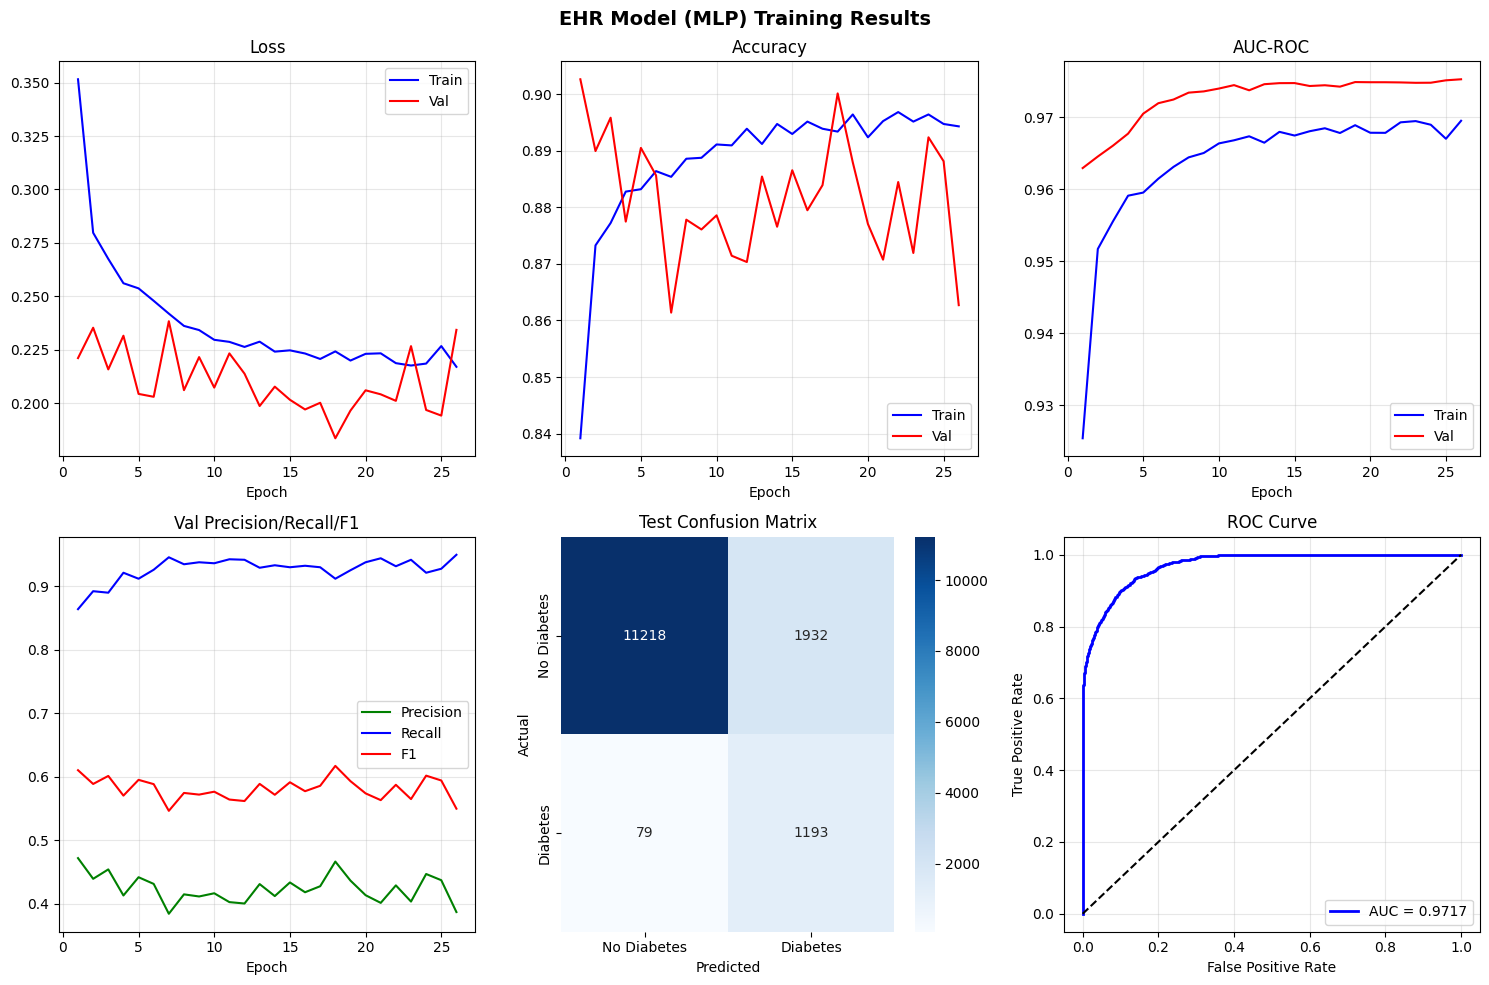

Saved: /content/drive/MyDrive/MULTIMODAL/models/ehr_training_results.png

TRAINING SUMMARY

Model: EHR MLP Classifier
─────────────────────────────────────────────────

Data (from preprocessing):
  Training samples:   11,876 (balanced: undersample)
  Validation samples: 14,422 (original distribution)
  Test samples:       14,422 (original distribution)
  Scaling:            standard

Architecture:
  Input features:     8
  Hidden layers:      [128, 64, 32]
  Feature dimension:  32
  Parameters:         11,969

Training:
  Epochs trained:     26
  Best epoch:         11
  Training time:      34.2s

Test Performance:
  Accuracy:           0.8606
  AUC-ROC:            0.9717
  Precision:          0.3818
  Recall:             0.9379
  F1-Score:           0.5426
  Specificity:        0.8531

Model saved to: /content/drive/MyDrive/MULTIMODAL/models/mlp_ehr_binary_diabetes.pth

─────────────────────────────────────────────────


UNIMODAL BASELINES COMPARISON

┌─────────────────┬──────────┬───

In [1]:
# """
# ================================================================================
# EHR Model (MLP) for Binary Diabetes Detection
# ================================================================================

# This notebook handles:
# 1. Loading preprocessed EHR datasets (pre-split and pre-scaled)
# 2. PyTorch MLP model definition
# 3. Model training with early stopping
# 4. Evaluation and metrics
# 5. Visualization
# 6. Model saving for multimodal fusion

# Input: ehr_train.csv, ehr_val.csv, ehr_test.csv (from preprocessing notebook)
# Output: mlp_ehr_binary_diabetes.pth

# Author: [Your Name]
# Date: 2025
# Project: Multimodal Federated Learning for Diabetes Detection
# ================================================================================
# """

# # ============================================================================
# # 1. IMPORTS
# # ============================================================================

# import os
# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader, TensorDataset
# from sklearn.metrics import (
#     accuracy_score, roc_auc_score, precision_score, recall_score,
#     f1_score, confusion_matrix, classification_report, roc_curve
# )
# import matplotlib.pyplot as plt
# import seaborn as sns
# import time
# import copy
# import json
# import pickle
# from typing import Dict, Tuple, List
# import warnings

# warnings.filterwarnings('ignore')

# print("=" * 70)
# print("EHR MODEL (MLP) TRAINING PIPELINE")
# print("=" * 70)

# # ============================================================================
# # 2. CONFIGURATION
# # ============================================================================

# class EHRModelConfig:
#     """Configuration for EHR model training."""

#     # Paths - UPDATE THESE IF NEEDED
#     DATA_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction"
#     SAVE_DIR = "/content/drive/MyDrive/MULTIMODAL/models"
#     MODEL_SAVE_NAME = "mlp_ehr_binary_diabetes.pth"

#     # Preprocessed file names (from preprocessing notebook)
#     TRAIN_FILE = "ehr_train.csv"
#     VAL_FILE = "ehr_val.csv"
#     TEST_FILE = "ehr_test.csv"
#     CONFIG_FILE = "ehr_preprocessing_config.json"
#     SCALER_FILE = "ehr_scaler.pkl"
#     ENCODERS_FILE = "ehr_encoders.json"

#     # Model architecture
#     HIDDEN_DIMS = [128, 64, 32]  # Hidden layer dimensions
#     DROPOUT_RATE = 0.3

#     # Training hyperparameters
#     BATCH_SIZE = 64
#     NUM_EPOCHS = 100
#     LEARNING_RATE = 1e-3
#     WEIGHT_DECAY = 1e-4

#     # Early stopping
#     PATIENCE = 15

#     # Device
#     DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     # Reproducibility
#     SEED = 42

# config = EHRModelConfig()

# # Create save directory
# os.makedirs(config.SAVE_DIR, exist_ok=True)


# def seed_everything(seed: int = 42):
#     """Set random seeds for reproducibility."""
#     import random
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

# seed_everything(config.SEED)

# print(f"\nDevice: {config.DEVICE}")
# print(f"Data directory: {config.DATA_DIR}")
# print(f"Model save path: {config.SAVE_DIR}/{config.MODEL_SAVE_NAME}")

# # ============================================================================
# # 3. LOAD PREPROCESSING CONFIGURATION
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 1: LOADING PREPROCESSING CONFIGURATION")
# print("=" * 70)

# # Load preprocessing config
# config_path = os.path.join(config.DATA_DIR, config.CONFIG_FILE)
# if not os.path.exists(config_path):
#     raise FileNotFoundError(
#         f"Preprocessing config not found at: {config_path}\n"
#         "Please run the preprocessing notebook first!"
#     )

# with open(config_path, 'r') as f:
#     preprocess_config = json.load(f)

# print(f"\nPreprocessing configuration loaded:")
# print(f"  Target column: {preprocess_config['target_column']}")
# print(f"  Scaling method: {preprocess_config['scaling_method']}")
# print(f"  Balancing strategy: {preprocess_config['balancing_strategy']}")
# print(f"  Balance train only: {preprocess_config['balance_train_only']}")
# print(f"  Feature order: {preprocess_config['feature_order']}")
# print(f"  Dataset sizes: {preprocess_config['dataset_sizes']}")

# # Extract key info
# TARGET_COLUMN = preprocess_config['target_column']
# FEATURE_NAMES = preprocess_config['feature_order']
# n_features = len(FEATURE_NAMES)

# print(f"\nNumber of features: {n_features}")

# # ============================================================================
# # 4. LOAD PREPROCESSED DATA
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 2: LOADING PREPROCESSED DATA")
# print("=" * 70)

# # Define file paths
# train_path = os.path.join(config.DATA_DIR, config.TRAIN_FILE)
# val_path = os.path.join(config.DATA_DIR, config.VAL_FILE)
# test_path = os.path.join(config.DATA_DIR, config.TEST_FILE)

# # Check if files exist
# for path, name in [(train_path, 'Train'), (val_path, 'Val'), (test_path, 'Test')]:
#     if not os.path.exists(path):
#         raise FileNotFoundError(
#             f"{name} data not found at: {path}\n"
#             "Please run the preprocessing notebook first!"
#         )

# # Load datasets
# df_train = pd.read_csv(train_path)
# df_val = pd.read_csv(val_path)
# df_test = pd.read_csv(test_path)

# print(f"\nDatasets loaded:")
# print(f"  Training:   {len(df_train):,} samples")
# print(f"  Validation: {len(df_val):,} samples")
# print(f"  Test:       {len(df_test):,} samples")

# # Verify columns match expected feature order
# expected_columns = FEATURE_NAMES + [TARGET_COLUMN]
# for df, name in [(df_train, 'Train'), (df_val, 'Val'), (df_test, 'Test')]:
#     if list(df.columns) != expected_columns:
#         print(f"\n⚠️  Warning: {name} columns don't match expected order")
#         print(f"  Expected: {expected_columns}")
#         print(f"  Found: {list(df.columns)}")

# # ============================================================================
# # 5. PREPARE DATA FOR TRAINING
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 3: PREPARING DATA FOR TRAINING")
# print("=" * 70)

# # Extract features and labels (data is already scaled from preprocessing)
# X_train = df_train[FEATURE_NAMES].values.astype(np.float32)
# y_train = df_train[TARGET_COLUMN].values.astype(np.float32)

# X_val = df_val[FEATURE_NAMES].values.astype(np.float32)
# y_val = df_val[TARGET_COLUMN].values.astype(np.float32)

# X_test = df_test[FEATURE_NAMES].values.astype(np.float32)
# y_test = df_test[TARGET_COLUMN].values.astype(np.float32)

# print(f"\nData shapes:")
# print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
# print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
# print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# print(f"\nClass distribution:")
# print(f"  Train - Class 0: {sum(y_train == 0):,} ({100*sum(y_train == 0)/len(y_train):.1f}%), "
#       f"Class 1: {sum(y_train == 1):,} ({100*sum(y_train == 1)/len(y_train):.1f}%)")
# print(f"  Val   - Class 0: {sum(y_val == 0):,} ({100*sum(y_val == 0)/len(y_val):.1f}%), "
#       f"Class 1: {sum(y_val == 1):,} ({100*sum(y_val == 1)/len(y_val):.1f}%)")
# print(f"  Test  - Class 0: {sum(y_test == 0):,} ({100*sum(y_test == 0)/len(y_test):.1f}%), "
#       f"Class 1: {sum(y_test == 1):,} ({100*sum(y_test == 1)/len(y_test):.1f}%)")

# # Note: Data is already scaled - no need to scale again
# print(f"\n✓ Data is pre-scaled (from preprocessing)")
# print(f"  Train data range: [{X_train.min():.2f}, {X_train.max():.2f}]")

# # ============================================================================
# # 6. CREATE DATALOADERS
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 4: CREATE DATALOADERS")
# print("=" * 70)

# # Convert to tensors
# X_train_t = torch.tensor(X_train, dtype=torch.float32)
# X_val_t = torch.tensor(X_val, dtype=torch.float32)
# X_test_t = torch.tensor(X_test, dtype=torch.float32)

# y_train_t = torch.tensor(y_train, dtype=torch.float32)
# y_val_t = torch.tensor(y_val, dtype=torch.float32)
# y_test_t = torch.tensor(y_test, dtype=torch.float32)

# # Create datasets
# train_dataset = TensorDataset(X_train_t, y_train_t)
# val_dataset = TensorDataset(X_val_t, y_val_t)
# test_dataset = TensorDataset(X_test_t, y_test_t)

# # Create dataloaders
# train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

# print(f"Train batches: {len(train_loader)}")
# print(f"Validation batches: {len(val_loader)}")
# print(f"Test batches: {len(test_loader)}")

# # ============================================================================
# # 7. MODEL DEFINITION
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 5: MODEL DEFINITION")
# print("=" * 70)


# class EHRClassifier(nn.Module):
#     """
#     Multi-Layer Perceptron for EHR tabular data classification.

#     Features:
#         - Flexible hidden layer configuration
#         - BatchNorm for training stability
#         - Dropout for regularization
#         - Feature extraction method for multimodal fusion

#     Architecture:
#         Input (n_features) → [Linear → BatchNorm → ReLU → Dropout] × n_layers → Sigmoid
#     """

#     def __init__(
#         self,
#         n_features: int,
#         hidden_dims: List[int] = [128, 64, 32],
#         dropout_rate: float = 0.3
#     ):
#         super(EHRClassifier, self).__init__()

#         self.n_features = n_features
#         self.hidden_dims = hidden_dims

#         # Build layers
#         layers = []
#         in_dim = n_features

#         for i, out_dim in enumerate(hidden_dims):
#             layers.extend([
#                 nn.Linear(in_dim, out_dim),
#                 nn.BatchNorm1d(out_dim),
#                 nn.ReLU(),
#                 nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
#             ])
#             in_dim = out_dim

#         self.feature_extractor = nn.Sequential(*layers)

#         # Feature dimension for multimodal fusion
#         self.feature_dim = hidden_dims[-1]

#         # Classification head
#         self.classifier = nn.Sequential(
#             nn.Linear(hidden_dims[-1], 1),
#             nn.Sigmoid()
#         )

#         # Initialize weights
#         self._init_weights()

#     def _init_weights(self):
#         """Initialize weights using Xavier initialization."""
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_uniform_(m.weight)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)

#     def extract_features(self, x: torch.Tensor) -> torch.Tensor:
#         """
#         Extract features for multimodal fusion.

#         Parameters
#         ----------
#         x : torch.Tensor
#             Input features of shape (B, n_features).

#         Returns
#         -------
#         torch.Tensor
#             Feature vector of shape (B, feature_dim).
#         """
#         return self.feature_extractor(x)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         """
#         Forward pass.

#         Parameters
#         ----------
#         x : torch.Tensor
#             Input features of shape (B, n_features).

#         Returns
#         -------
#         torch.Tensor
#             Binary predictions of shape (B, 1), values in [0, 1].
#         """
#         features = self.feature_extractor(x)
#         output = self.classifier(features)
#         return output


# # Create model
# model = EHRClassifier(
#     n_features=n_features,
#     hidden_dims=config.HIDDEN_DIMS,
#     dropout_rate=config.DROPOUT_RATE
# )
# model = model.to(config.DEVICE)

# # Print model summary
# total_params = sum(p.numel() for p in model.parameters())
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# print(f"\nModel Architecture:")
# print(f"  Input features: {n_features}")
# print(f"  Hidden layers: {config.HIDDEN_DIMS}")
# print(f"  Feature dimension (for fusion): {model.feature_dim}")
# print(f"  Total parameters: {total_params:,}")
# print(f"  Trainable parameters: {trainable_params:,}")

# print(f"\nModel structure:")
# print(model)

# # ============================================================================
# # 8. TRAINING UTILITIES
# # ============================================================================


# class EarlyStopping:
#     """Early stopping to prevent overfitting."""

#     def __init__(self, patience: int = 15, min_delta: float = 0.001, mode: str = 'max'):
#         self.patience = patience
#         self.min_delta = min_delta
#         self.mode = mode
#         self.counter = 0
#         self.best_score = None
#         self.early_stop = False
#         self.best_epoch = 0

#     def __call__(self, score: float, epoch: int) -> bool:
#         if self.best_score is None:
#             self.best_score = score
#             self.best_epoch = epoch
#         elif self._is_improvement(score):
#             self.best_score = score
#             self.best_epoch = epoch
#             self.counter = 0
#         else:
#             self.counter += 1
#             if self.counter >= self.patience:
#                 self.early_stop = True
#         return self.early_stop

#     def _is_improvement(self, score: float) -> bool:
#         if self.mode == 'min':
#             return score < self.best_score - self.min_delta
#         return score > self.best_score + self.min_delta


# class MetricsTracker:
#     """Track training metrics."""

#     def __init__(self):
#         self.history = {
#             'train_loss': [], 'train_acc': [], 'train_auc': [],
#             'val_loss': [], 'val_acc': [], 'val_auc': [],
#             'val_precision': [], 'val_recall': [], 'val_f1': [],
#             'learning_rate': []
#         }

#     def update(self, metrics: Dict[str, float]):
#         for key, value in metrics.items():
#             if key in self.history:
#                 self.history[key].append(value)

#     def get_best_metrics(self) -> Dict[str, float]:
#         if not self.history['val_auc']:
#             return {}
#         best_idx = np.argmax(self.history['val_auc'])
#         return {
#             'epoch': best_idx + 1,
#             'val_auc': self.history['val_auc'][best_idx],
#             'val_acc': self.history['val_acc'][best_idx],
#             'val_f1': self.history['val_f1'][best_idx]
#         }


# # ============================================================================
# # 9. TRAINING FUNCTIONS
# # ============================================================================


# def train_one_epoch(model, loader, criterion, optimizer, device):
#     """Train for one epoch."""
#     model.train()
#     running_loss = 0.0
#     all_preds = []
#     all_labels = []

#     for X_batch, y_batch in loader:
#         X_batch = X_batch.to(device)
#         y_batch = y_batch.to(device).unsqueeze(1)

#         optimizer.zero_grad()
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         running_loss += loss.item() * X_batch.size(0)
#         all_preds.extend(outputs.detach().cpu().numpy().flatten())
#         all_labels.extend(y_batch.detach().cpu().numpy().flatten())

#     epoch_loss = running_loss / len(loader.dataset)
#     all_preds = np.array(all_preds)
#     all_labels = np.array(all_labels)

#     epoch_acc = accuracy_score(all_labels, (all_preds > 0.5).astype(int))
#     try:
#         epoch_auc = roc_auc_score(all_labels, all_preds)
#     except:
#         epoch_auc = 0.5

#     return {'loss': epoch_loss, 'accuracy': epoch_acc, 'auc': epoch_auc}


# def validate(model, loader, criterion, device):
#     """Validate the model."""
#     model.eval()
#     running_loss = 0.0
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for X_batch, y_batch in loader:
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device).unsqueeze(1)

#             outputs = model(X_batch)
#             loss = criterion(outputs, y_batch)

#             running_loss += loss.item() * X_batch.size(0)
#             all_preds.extend(outputs.cpu().numpy().flatten())
#             all_labels.extend(y_batch.cpu().numpy().flatten())

#     epoch_loss = running_loss / len(loader.dataset)
#     all_preds = np.array(all_preds)
#     all_labels = np.array(all_labels)
#     all_preds_binary = (all_preds > 0.5).astype(int)

#     try:
#         auc = roc_auc_score(all_labels, all_preds)
#     except:
#         auc = 0.5

#     metrics = {
#         'loss': epoch_loss,
#         'accuracy': accuracy_score(all_labels, all_preds_binary),
#         'auc': auc,
#         'precision': precision_score(all_labels, all_preds_binary, zero_division=0),
#         'recall': recall_score(all_labels, all_preds_binary, zero_division=0),
#         'f1': f1_score(all_labels, all_preds_binary, zero_division=0)
#     }

#     return metrics, all_preds, all_labels


# # ============================================================================
# # 10. TRAINING LOOP
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 6: MODEL TRAINING")
# print("=" * 70)
# print(f"\nTraining configuration:")
# print(f"  Epochs: {config.NUM_EPOCHS}")
# print(f"  Batch size: {config.BATCH_SIZE}")
# print(f"  Learning rate: {config.LEARNING_RATE}")
# print(f"  Early stopping patience: {config.PATIENCE}")
# print(f"  Device: {config.DEVICE}")
# print("=" * 70 + "\n")

# # Loss and optimizer
# criterion = nn.BCELoss()
# optimizer = optim.AdamW(
#     model.parameters(),
#     lr=config.LEARNING_RATE,
#     weight_decay=config.WEIGHT_DECAY
# )
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
# )

# # Initialize tracking
# metrics_tracker = MetricsTracker()
# early_stopping = EarlyStopping(patience=config.PATIENCE, mode='max')
# best_model_state = None
# best_val_auc = 0.0

# start_time = time.time()

# for epoch in range(1, config.NUM_EPOCHS + 1):
#     # Train
#     train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, config.DEVICE)

#     # Validate
#     val_metrics, val_preds, val_labels = validate(model, val_loader, criterion, config.DEVICE)

#     # Update scheduler
#     current_lr = optimizer.param_groups[0]['lr']
#     scheduler.step(val_metrics['auc'])

#     # Track metrics
#     metrics_tracker.update({
#         'train_loss': train_metrics['loss'],
#         'train_acc': train_metrics['accuracy'],
#         'train_auc': train_metrics['auc'],
#         'val_loss': val_metrics['loss'],
#         'val_acc': val_metrics['accuracy'],
#         'val_auc': val_metrics['auc'],
#         'val_precision': val_metrics['precision'],
#         'val_recall': val_metrics['recall'],
#         'val_f1': val_metrics['f1'],
#         'learning_rate': current_lr
#     })

#     # Print progress
#     if epoch % 10 == 0 or epoch == 1 or val_metrics['auc'] > best_val_auc:
#         print(f"Epoch {epoch:3d} | "
#               f"Train Loss: {train_metrics['loss']:.4f} | "
#               f"Val AUC: {val_metrics['auc']:.4f} | "
#               f"Val Acc: {val_metrics['accuracy']:.4f}", end="")
#         if val_metrics['auc'] > best_val_auc:
#             print(" ✓ Best!", end="")
#         print()

#     # Save best model
#     if val_metrics['auc'] > best_val_auc:
#         best_val_auc = val_metrics['auc']
#         best_model_state = copy.deepcopy(model.state_dict())

#         # Save checkpoint with preprocessing info
#         checkpoint_path = os.path.join(config.SAVE_DIR, config.MODEL_SAVE_NAME)
#         torch.save({
#             'epoch': epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'val_auc': val_metrics['auc'],
#             'val_acc': val_metrics['accuracy'],
#             'n_features': n_features,
#             'feature_names': FEATURE_NAMES,
#             'hidden_dims': config.HIDDEN_DIMS,
#             'feature_dim': model.feature_dim,
#             'dropout_rate': config.DROPOUT_RATE,
#             # Reference to preprocessing config
#             'preprocess_config': preprocess_config,
#             'data_dir': config.DATA_DIR,
#         }, checkpoint_path)

#     # Early stopping
#     if early_stopping(val_metrics['auc'], epoch):
#         print(f"\n⚠ Early stopping at epoch {epoch}")
#         print(f"  Best epoch: {early_stopping.best_epoch} with AUC: {early_stopping.best_score:.4f}")
#         break

# total_time = time.time() - start_time

# print("\n" + "=" * 70)
# print("TRAINING COMPLETED")
# print("=" * 70)
# print(f"Total time: {total_time:.1f} seconds ({total_time/60:.2f} minutes)")
# print(f"Best validation AUC: {best_val_auc:.4f}")

# # Load best model
# if best_model_state is not None:
#     model.load_state_dict(best_model_state)

# # ============================================================================
# # 11. FINAL EVALUATION
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 7: FINAL EVALUATION ON TEST SET")
# print("=" * 70)

# test_metrics, test_preds, test_labels = validate(model, test_loader, criterion, config.DEVICE)

# print(f"\nTest Results:")
# print(f"  Accuracy:    {test_metrics['accuracy']:.4f}")
# print(f"  AUC-ROC:     {test_metrics['auc']:.4f}")
# print(f"  Precision:   {test_metrics['precision']:.4f}")
# print(f"  Recall:      {test_metrics['recall']:.4f}")
# print(f"  F1-Score:    {test_metrics['f1']:.4f}")

# # Calculate specificity
# test_preds_binary = (np.array(test_preds) > 0.5).astype(int)
# tn, fp, fn, tp = confusion_matrix(test_labels, test_preds_binary).ravel()
# specificity = tn / (tn + fp)
# print(f"  Specificity: {specificity:.4f}")

# print("\nClassification Report:")
# print(classification_report(
#     test_labels, test_preds_binary,
#     target_names=['No Diabetes (0)', 'Diabetes (1)']
# ))

# cm = confusion_matrix(test_labels, test_preds_binary)
# print("Confusion Matrix:")
# print(cm)

# # ============================================================================
# # 12. VISUALIZATION
# # ============================================================================

# print("\n" + "=" * 70)
# print("STEP 8: VISUALIZATION")
# print("=" * 70)

# history = metrics_tracker.history
# epochs = range(1, len(history['train_loss']) + 1)

# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# fig.suptitle('EHR Model (MLP) Training Results', fontsize=14, fontweight='bold')

# # Loss
# axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train')
# axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val')
# axes[0, 0].set_title('Loss')
# axes[0, 0].set_xlabel('Epoch')
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3)

# # Accuracy
# axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train')
# axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val')
# axes[0, 1].set_title('Accuracy')
# axes[0, 1].set_xlabel('Epoch')
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)

# # AUC
# axes[0, 2].plot(epochs, history['train_auc'], 'b-', label='Train')
# axes[0, 2].plot(epochs, history['val_auc'], 'r-', label='Val')
# axes[0, 2].set_title('AUC-ROC')
# axes[0, 2].set_xlabel('Epoch')
# axes[0, 2].legend()
# axes[0, 2].grid(True, alpha=0.3)

# # Precision/Recall/F1
# axes[1, 0].plot(epochs, history['val_precision'], 'g-', label='Precision')
# axes[1, 0].plot(epochs, history['val_recall'], 'b-', label='Recall')
# axes[1, 0].plot(epochs, history['val_f1'], 'r-', label='F1')
# axes[1, 0].set_title('Val Precision/Recall/F1')
# axes[1, 0].set_xlabel('Epoch')
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # Confusion Matrix
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
#             xticklabels=['No Diabetes', 'Diabetes'],
#             yticklabels=['No Diabetes', 'Diabetes'])
# axes[1, 1].set_title('Test Confusion Matrix')
# axes[1, 1].set_xlabel('Predicted')
# axes[1, 1].set_ylabel('Actual')

# # ROC Curve
# fpr, tpr, _ = roc_curve(test_labels, test_preds)
# auc_score = roc_auc_score(test_labels, test_preds)
# axes[1, 2].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_score:.4f}')
# axes[1, 2].plot([0, 1], [0, 1], 'k--')
# axes[1, 2].set_title('ROC Curve')
# axes[1, 2].set_xlabel('False Positive Rate')
# axes[1, 2].set_ylabel('True Positive Rate')
# axes[1, 2].legend()
# axes[1, 2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(f"{config.SAVE_DIR}/ehr_training_results.png", dpi=150, bbox_inches='tight')
# plt.show()
# print(f"Saved: {config.SAVE_DIR}/ehr_training_results.png")

# # ============================================================================
# # 13. SUMMARY
# # ============================================================================

# print("\n" + "=" * 70)
# print("TRAINING SUMMARY")
# print("=" * 70)

# print(f"""
# Model: EHR MLP Classifier
# ─────────────────────────────────────────────────

# Data (from preprocessing):
#   Training samples:   {len(df_train):,} (balanced: {preprocess_config['balancing_strategy']})
#   Validation samples: {len(df_val):,} (original distribution)
#   Test samples:       {len(df_test):,} (original distribution)
#   Scaling:            {preprocess_config['scaling_method']}

# Architecture:
#   Input features:     {n_features}
#   Hidden layers:      {config.HIDDEN_DIMS}
#   Feature dimension:  {model.feature_dim}
#   Parameters:         {total_params:,}

# Training:
#   Epochs trained:     {len(history['train_loss'])}
#   Best epoch:         {early_stopping.best_epoch}
#   Training time:      {total_time:.1f}s

# Test Performance:
#   Accuracy:           {test_metrics['accuracy']:.4f}
#   AUC-ROC:            {test_metrics['auc']:.4f}
#   Precision:          {test_metrics['precision']:.4f}
#   Recall:             {test_metrics['recall']:.4f}
#   F1-Score:           {test_metrics['f1']:.4f}
#   Specificity:        {specificity:.4f}

# Model saved to: {config.SAVE_DIR}/{config.MODEL_SAVE_NAME}

# ─────────────────────────────────────────────────
# """)

# # ============================================================================
# # 14. COMPARISON WITH CNN MODEL
# # ============================================================================

# print("\n" + "=" * 70)
# print("UNIMODAL BASELINES COMPARISON")
# print("=" * 70)

# print(f"""
# ┌─────────────────┬──────────┬──────────┬──────────┬─────────────┐
# │ Model           │ AUC      │ Accuracy │ F1       │ Feature Dim │
# ├─────────────────┼──────────┼──────────┼──────────┼─────────────┤
# │ Retinal CNN     │ 0.759    │ 0.717    │ 0.580    │ 1280        │
# │ EHR MLP         │ {test_metrics['auc']:.3f}    │ {test_metrics['accuracy']:.3f}    │ {test_metrics['f1']:.3f}    │ {model.feature_dim}          │
# └─────────────────┴──────────┴──────────┴──────────┴─────────────┘
# """)

# print("\n" + "=" * 70)
# print("NEXT STEPS")
# print("=" * 70)

# print("""
# ✓ EHR Model training complete!

# Ready for STEP 3: Multimodal Fusion
# ───────────────────────────────────

# For feature extraction (multimodal fusion):

#   # Load EHR model
#   checkpoint = torch.load('mlp_ehr_binary_diabetes.pth')
#   ehr_model = EHRClassifier(
#       n_features=checkpoint['n_features'],
#       hidden_dims=checkpoint['hidden_dims'],
#       dropout_rate=checkpoint.get('dropout_rate', 0.3)
#   )
#   ehr_model.load_state_dict(checkpoint['model_state_dict'])

#   # Extract features
#   ehr_features = ehr_model.extract_features(ehr_data)  # Shape: (B, 32)

#   # Load CNN model
#   cnn_features = cnn_model.extract_features(images)    # Shape: (B, 1280)

#   # Concatenate for fusion
#   fused_features = torch.cat([cnn_features, ehr_features], dim=1)  # Shape: (B, 1312)
# """)

# # ============================================================================
# # 15. HELPER CODE FOR LOADING MODEL
# # ============================================================================

# print("\n" + "=" * 70)
# print("HELPER CODE FOR LOADING TRAINED MODEL")
# print("=" * 70)

# helper_code = '''
# # ============================================================================
# # Copy this code to load the trained EHR model in other notebooks
# # ============================================================================

# import torch
# import torch.nn as nn
# from typing import List

# class EHRClassifier(nn.Module):
#     """MLP for EHR tabular data classification."""

#     def __init__(self, n_features: int, hidden_dims: List[int] = [128, 64, 32], dropout_rate: float = 0.3):
#         super(EHRClassifier, self).__init__()
#         self.n_features = n_features
#         self.hidden_dims = hidden_dims

#         layers = []
#         in_dim = n_features
#         for i, out_dim in enumerate(hidden_dims):
#             layers.extend([
#                 nn.Linear(in_dim, out_dim),
#                 nn.BatchNorm1d(out_dim),
#                 nn.ReLU(),
#                 nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
#             ])
#             in_dim = out_dim

#         self.feature_extractor = nn.Sequential(*layers)
#         self.feature_dim = hidden_dims[-1]
#         self.classifier = nn.Sequential(nn.Linear(hidden_dims[-1], 1), nn.Sigmoid())

#     def extract_features(self, x):
#         return self.feature_extractor(x)

#     def forward(self, x):
#         features = self.feature_extractor(x)
#         return self.classifier(features)


# def load_ehr_model(checkpoint_path, device='cpu'):
#     """Load trained EHR model from checkpoint."""
#     checkpoint = torch.load(checkpoint_path, map_location=device)

#     model = EHRClassifier(
#         n_features=checkpoint['n_features'],
#         hidden_dims=checkpoint['hidden_dims'],
#         dropout_rate=checkpoint.get('dropout_rate', 0.3)
#     )
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.to(device)
#     model.eval()

#     return model, checkpoint


# # Usage:
# # model, checkpoint = load_ehr_model('/path/to/mlp_ehr_binary_diabetes.pth')
# # print(f"Feature names: {checkpoint['feature_names']}")
# # print(f"Preprocessing config: {checkpoint['preprocess_config']}")
# '''

# print(helper_code)

# print("\n" + "=" * 70)
# print("✓ PIPELINE COMPLETE")
# print("=" * 70)